# Test State Injection Operations

Tests `state_injection`, `logical_unencode`, and `logical_shrink` for Rotated Surface Code across distances, protocols, and injected states.

In [1]:
import sys
import os
import numpy as np

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from experiments.state_injection import StateInjectionExperiment

## 1. Build circuits (no noise)

Build injection circuits for different Distance, Protocol (corner/middle), and inject_state (Z->|0⟩, X->|+⟩).

In [2]:
results = []
for d in [3, 5]:
    for protocol in ['corner', 'middle']:
        for inject_state in ['Z', 'X']:
            exp = StateInjectionExperiment(
                distance=d,
                rounds=2,
                injection_protocol=protocol,
                inject_state=inject_state,
                noise_params=None,
            )
            circ = exp.build()
            results.append({
                'distance': d,
                'protocol': protocol,
                'inject_state': inject_state,
                'circuit': circ,
                'num_ops': len(circ),
            })
            print(f'd={d} {protocol} {inject_state}: {len(circ)} ops')

Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=3 corner Z: 43 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=3 corner X: 43 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=3 middle Z: 44 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=3 middle X: 44 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=5 corner Z: 90 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=5 corner X: 90 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=5 middle Z: 92 ops
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
d=5 middle X: 92 ops


## 2. Verify correctness by sampling (noiseless)

With zero noise, the circuit is deterministic. Sample multiple shots and check that the logical observable matches the injected state.

In [3]:
n_shots = 100
all_pass = True
for r in results:
    circ = r['circuit']
    sampler = circ.compile_detector_sampler()
    dets, obs = sampler.sample(shots=n_shots, separate_observables=True)
    # obs shape: (n_shots, n_observables). For single logical, obs[:, 0]
    # Ideal |0⟩ (Z) and |+⟩ (X) both yield observable 0 in noiseless case
    if not np.all(obs == 0):
        all_pass = False
        print(f"FAIL d={r['distance']} {r['protocol']} {r['inject_state']}: obs={obs[:, 0][:5]}...")
    else:
        print(f"OK d={r['distance']} {r['protocol']} {r['inject_state']}: {n_shots} shots, obs=0 (correct)")

print("\n" + ("All tests passed!" if all_pass else "Some tests failed."))

OK d=3 corner Z: 100 shots, obs=0 (correct)
OK d=3 corner X: 100 shots, obs=0 (correct)
OK d=3 middle Z: 100 shots, obs=0 (correct)
OK d=3 middle X: 100 shots, obs=0 (correct)
OK d=5 corner Z: 100 shots, obs=0 (correct)
OK d=5 corner X: 100 shots, obs=0 (correct)
OK d=5 middle Z: 100 shots, obs=0 (correct)
OK d=5 middle X: 100 shots, obs=0 (correct)

All tests passed!


## 2b. Y-basis state injection

Y-basis injection prepares the logical |+i⟩ = (|0⟩ + i|1⟩)/√2 eigenstate via `inject_state='Y'`.

The injection qubit is reset with `RY` (Stim's +Y eigenstate reset). Surrounding qubits use the same X/Z diagonal split as X injection. Post-selection on round-1 detectors handles stochastic stabilizer outcomes.

Checks:
- `RY` appears in the circuit (injection qubit initialized in |+i⟩)
- Noiseless sampling: observable is always 0
- Detector structure matches the X/Z injection pattern (same number of detectors)

In [4]:
n_shots  = 200
all_pass = True

print("Y-basis injection — build and noiseless correctness check")
print(f"{'d':>2} {'protocol':>8} {'inject':>6}  {'n_ops':>6}  {'n_det':>6}  {'RY_present':>11}  {'obs_all_zero':>12}")
print("-" * 72)

for d in [3, 5]:
    for protocol in ["corner", "middle"]:
        exp  = StateInjectionExperiment(
            distance=d, rounds=2,
            injection_protocol=protocol, inject_state="Y",
            noise_params=None,
        )
        circ = exp.build()

        # Check RY appears (injection qubit initialized to |+i>)
        has_ry = any(
            inst.name == "RY"
            for inst in circ.flattened()
        )

        # Noiseless sampling: observable must always be 0
        dets, obs = circ.compile_detector_sampler().sample(
            shots=n_shots, separate_observables=True
        )
        obs_ok = bool(np.all(obs == 0))

        det_coords = circ.get_detector_coordinates()

        ok = has_ry and obs_ok
        if not ok:
            all_pass = False
        flag = "OK" if ok else "FAIL"
        print(
            f"{d:>2} {protocol:>8}      Y  {len(circ):>6}  {len(det_coords):>6}"
            f"  {'yes' if has_ry else 'NO':>11}  {'yes' if obs_ok else 'NO':>12}  {flag}"
        )

print()
print("All passed ✓" if all_pass else "SOME FAILED ✗")

Y-basis injection — build and noiseless correctness check
 d protocol inject   n_ops   n_det   RY_present  obs_all_zero
------------------------------------------------------------------------
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
 3   corner      Y      41      11          yes           yes  OK
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
 3   middle      Y      42      12          yes           yes  OK
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
 5   corner      Y      80      34          yes           yes  OK
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
 5   middle      Y      82      36          yes           yes  OK

All passed ✓


## 3. `logical_shrink` — unit tests

`logical_shrink` measures all data qubits **except** the corner (1,1) in their initialization basis, emits data-only DETECTOR instructions for pure-region stabilizers, and returns the global index of the corner qubit for subsequent operations.

| Region | Init basis | Shrink measurement |
|--------|-----------|-------------------|
| Corner (1,1) | inject_state | **not measured** |
| Lower diagonal (y ≥ x, not corner) | X | **MX** |
| Upper diagonal (y < x) | Z | **M** |

Data-only DETECTOR instructions are emitted for:
- Z-stabilizers whose ancilla satisfies `ax > ay` (support entirely in upper diagonal)
- X-stabilizers whose ancilla satisfies `ax < ay` (support entirely in lower diagonal)

Expected detector counts for d=3, rounds=2:
| Block | Count |
|-------|-------|
| Round-1 syndrome (tagged post-select) | 3 |
| Round-2 XOR syndrome | 8 |
| Shrink data-only | 3 |
| **Total** | **14** |

Compare: `logical_unencode` produces 15 detectors (3 + 8 + 4 final-readout).

In [5]:
import stim
from collections import Counter
from src.qec_code.surface_code.rotated import (
    RotatedSurfaceCode,
    RotatedSurfaceCodeExtractionBlock,
    RotatedSurfaceCodeLogicalOpSet,
)
from src.ir.qec_system import QECSystem
from src.ir.tracker import SyndromeTracker
from src.ir.builder import CircuitBuilder


def build_shrink_circuit(distance=3, rounds=2, inject_state="Z", noise_params=None):
    """
    Build: state_injection → SE → logical_shrink.

    logical_shrink is a building block — it does not add a logical observable.
    The corner qubit (returned index) carries the logical information forward.

    Args:
        noise_params: NoiseConfig — if given, applies circuit-level noise.

    Returns:
        (circuit, corner_q)
    """
    patch   = RotatedSurfaceCode(distance=distance)
    system  = QECSystem()
    system.add_patch(patch, name="sc")
    tracker = SyndromeTracker(
        num_qubits=system.num_qubits, expected_num_logicals=system.num_logicals
    )
    builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=True)
    op_set  = RotatedSurfaceCodeLogicalOpSet()

    builder.write_coordinates()
    op_set.state_injection(builder, patch, inject_state=inject_state, protocol="corner")
    se_block = RotatedSurfaceCodeExtractionBlock(system)
    builder.apply_syndrome_extraction(se_block.circuit, rounds=rounds)
    corner_q = op_set.logical_shrink(builder, patch, inject_state=inject_state)

    if noise_params is not None:
        return builder.build_noisy_circuit(noise_params=noise_params, noise_model="circuit_level"), corner_q
    return builder.circuit, corner_q


# ── Structure checks ──────────────────────────────────────────────────────────
shrink_circuits = {}   # (d, rounds, inject_state) -> circuit
expected = {(3, 2): 14, (5, 2): 44}   # expected total detector count

print(f"{'d':>2} {'inject':>6} {'rounds':>6}  {'corner_q':>8}  {'n_det':>5}  time→count")
print("-" * 65)

all_pass = True
for d, rounds in [(3, 2), (5, 2)]:
    for inject_state in ["Z", "X"]:
        circ, corner_q = build_shrink_circuit(d, rounds, inject_state)
        det_c  = circ.get_detector_coordinates()
        n_det  = len(det_c)
        t_cnt  = Counter(int(c[2]) if len(c) > 2 else -1 for c in det_c.values())
        exp    = expected.get((d, rounds))
        ok     = (n_det == exp) if exp is not None else True
        if not ok:
            all_pass = False
        shrink_circuits[(d, rounds, inject_state)] = circ
        flag = " ✓" if ok else f" ✗ (expected {exp})"
        print(
            f"{d:>2} {inject_state:>6}      {rounds:>2}        {corner_q:>3}    {n_det:>3}{flag}"
            f"  {dict(sorted(t_cnt.items()))}"
        )

print()
print("Detector counts: " + ("all correct ✓" if all_pass else "MISMATCH ✗"))

 d inject rounds  corner_q  n_det  time→count
-----------------------------------------------------------------
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
 3      Z       2          1     14 ✓  {0: 3, 1: 11}
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
 3      X       2          1     14 ✓  {0: 3, 1: 11}
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
 5      Z       2          2     44 ✓  {0: 10, 1: 34}
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
 5      X       2          2     44 ✓  {0: 10, 1: 34}

Detector counts: all correct ✓


In [6]:
# ── Noiseless correctness: sample detectors and verify all-zero ───────────────
# logical_shrink is a building block (no logical observable in the circuit).
# In the noiseless case, no detector should fire.

n_shots  = 200
all_pass = True

print(f"Sampling {n_shots} noiseless shots from each shrink circuit:")
print()
for (d, rounds, inject_state), circ in shrink_circuits.items():
    # compile_detector_sampler returns only detector bits
    dets = circ.compile_detector_sampler().sample(n_shots)
    no_dets = not dets.any()
    if not no_dets:
        all_pass = False
        fired = np.where(dets.any(axis=0))[0].tolist()
        print(f"FAIL d={d} rounds={rounds} inject={inject_state} — detectors fired: {fired}")
    else:
        print(f"OK   d={d} rounds={rounds} inject={inject_state} — no detection events")

print()
print("All passed ✓" if all_pass else "SOME FAILED ✗")

Sampling 200 noiseless shots from each shrink circuit:

OK   d=3 rounds=2 inject=Z — no detection events
OK   d=3 rounds=2 inject=X — no detection events
OK   d=5 rounds=2 inject=Z — no detection events
OK   d=5 rounds=2 inject=X — no detection events

All passed ✓


## 4. Circuit diagram — d=3, corner injection, Z state

Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...


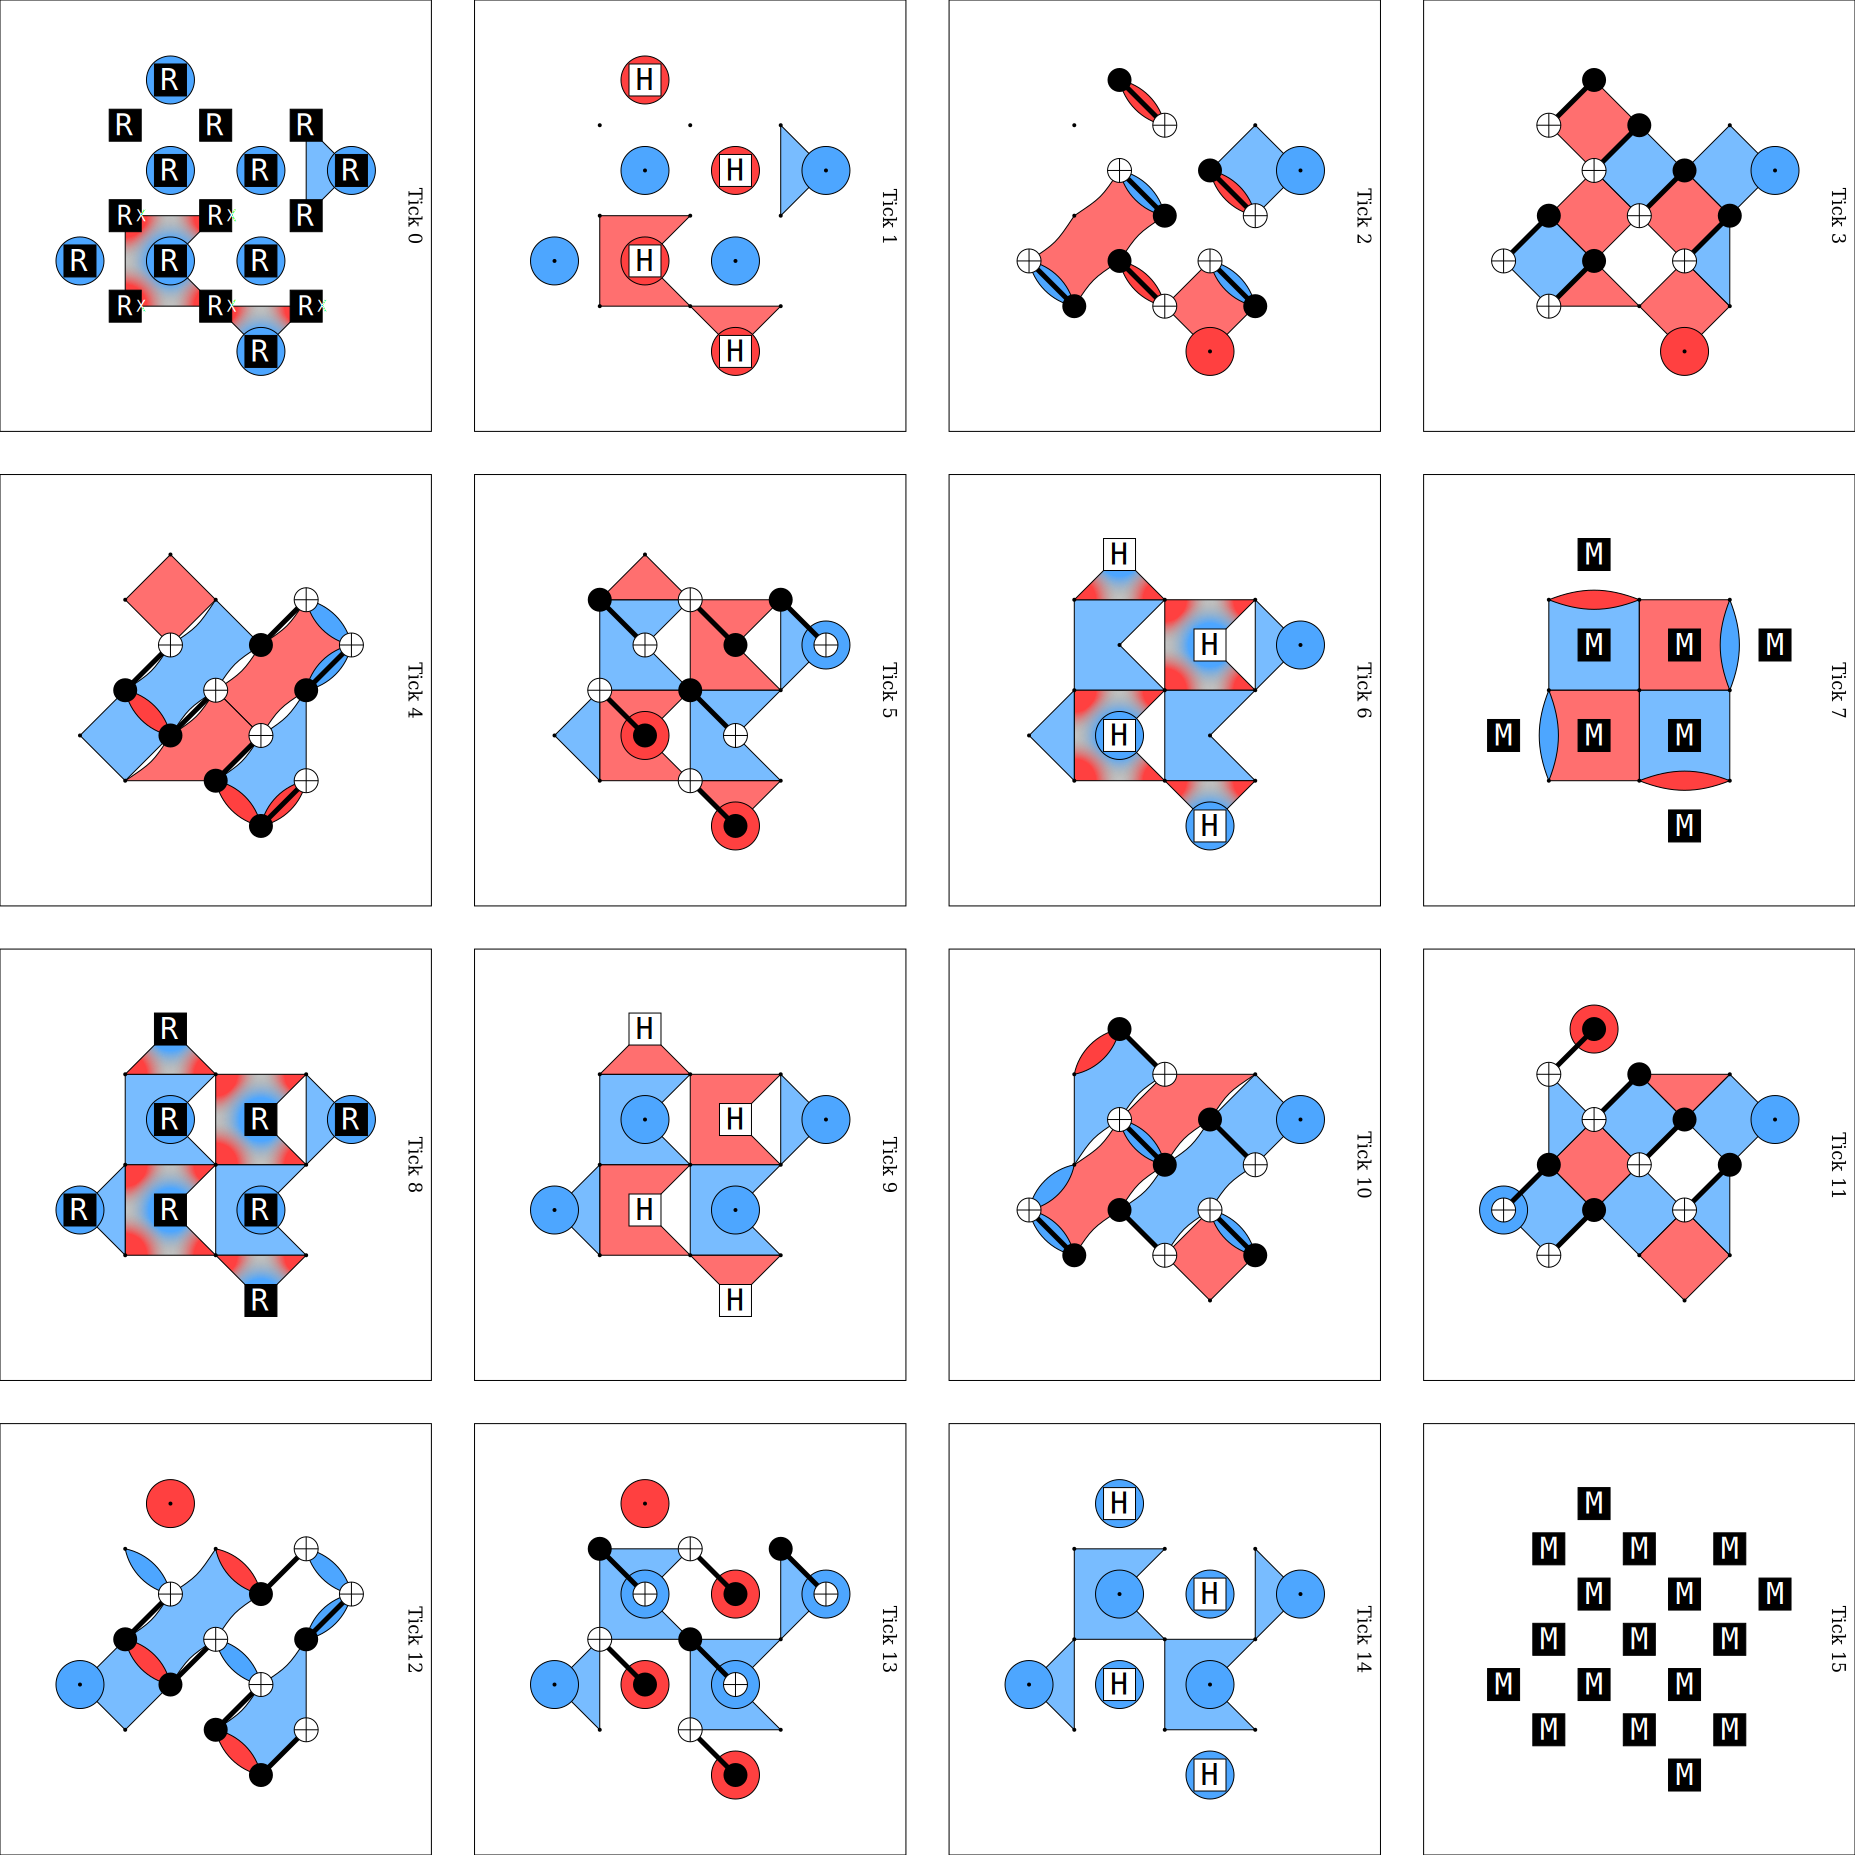

In [7]:
exp = StateInjectionExperiment(distance=3, rounds=2, injection_protocol='corner', inject_state='Z')
circ = exp.build()
circ.without_noise().diagram('detslice-with-ops-svg')

## 5. Composable API via `LogicalExecutor`

`StateInjectionExperiment` is a convenience wrapper. The same circuit can be assembled step-by-step using the composable API, which is the intended entry-point for multi-step experiments.

| Method | Dispatched via executor | Return value |
|--------|------------------------|--------------|
| `state_injection(builder, patch, inject_state, protocol)` | ✓ | — |
| `logical_unencode(builder, patch, inject_state)` | ✓ | — |
| `logical_shrink(builder, patch, inject_state)` | call directly | corner qubit index |

Note: `logical_shrink` must be called directly (not via `executor.apply_logical_operation`) because its return value (corner qubit index) is needed for subsequent steps.

In [8]:
from src.ir.logical_executor import LogicalExecutor

D            = 3
ROUNDS       = 2
INJECT_STATE = "Z"
PROTOCOL     = "corner"

# ── 1. Build system ──────────────────────────────────────────────────────────
patch  = RotatedSurfaceCode(distance=D)
system = QECSystem()
system.add_patch(patch, name="surface_code")

# ── 2. Build tracker + builder ───────────────────────────────────────────────
tracker = SyndromeTracker(
    num_qubits=system.num_qubits,
    expected_num_logicals=system.num_logicals,
)
builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=True)

# ── 3. Wire up LogicalExecutor ───────────────────────────────────────────────
op_set   = RotatedSurfaceCodeLogicalOpSet()
executor = LogicalExecutor(builder)
executor.register_op_set(RotatedSurfaceCode, op_set)

# ── 4. Build circuit: injection → SE rounds → unencode ──────────────────────
builder.write_coordinates()

executor.apply_logical_operation(
    "state_injection", [patch],
    inject_state=INJECT_STATE, protocol=PROTOCOL,
)

se_block = RotatedSurfaceCodeExtractionBlock(system)
builder.apply_syndrome_extraction(se_block.circuit, rounds=ROUNDS)

executor.apply_logical_operation(
    "logical_unencode", [patch],
    inject_state=INJECT_STATE,
)

circ_executor = builder.circuit

# ── 5. Inspect circuit ───────────────────────────────────────────────────────
det_coords = circ_executor.get_detector_coordinates()
max_t      = max(c[2] if len(c) > 2 else 0 for c in det_coords.values())
n_se       = sum(1 for c in det_coords.values() if len(c) > 2 and c[2] < max_t)
n_rd       = sum(1 for c in det_coords.values() if len(c) > 2 and c[2] == max_t)

print("Built via LogicalExecutor:")
print(f"  Total detectors  : {len(det_coords)}")
print(f"  syndrome-round   : {n_se}")
print(f"  final-readout    : {n_rd}")

Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Built via LogicalExecutor:
  Total detectors  : 15
  syndrome-round   : 11
  final-readout    : 4


### 5.1 Verify: circuit matches `StateInjectionExperiment` output

In [9]:
ref_exp  = StateInjectionExperiment(
    distance=D, rounds=ROUNDS,
    injection_protocol=PROTOCOL, inject_state=INJECT_STATE,
)
ref_circ = ref_exp.build()

match = circ_executor.without_noise() == ref_circ.without_noise()
print("Circuits match StateInjectionExperiment:", match)
assert match, "Circuits differ — check builder and experiment implementations!"

Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Circuits match StateInjectionExperiment: True


## 6. Noisy sampling — post_rate comparison

Compare `logical_unencode` and `logical_shrink` under circuit-level noise (`p_2q = 1e-3`).

Post-selection uses all syndrome-round detectors tagged `[post-select]` — 11 detectors for d=3, rounds=2.

Since `logical_shrink` is a building block (no logical observable), the comparison shows:
- `logical_unencode`: full LER (no-PS and post-selected)
- `logical_shrink`: post-selection rate only

Both circuits share the same 11 syndrome-round detectors, so their post_rate should match.

In [10]:
from src.noise.config import NoiseConfig
from src.simulation.decoder_backend.post_select import (
    get_post_select_detector_indices,
    apply_post_selection,
)

P2      = 1e-3
N_SHOTS = 100_000
D_COMP  = 3
ROUNDS_COMP = 2
noise   = NoiseConfig(p_2q=P2)

print(f"d={D_COMP}, rounds={ROUNDS_COMP}, p_2q={P2:.0e}, n_shots={N_SHOTS:,}")
print()
print(f"{'Method':>22} {'inject':>6}  {'ps_dets':>8} {'post_rate':>10} {'LER(noPS)':>11} {'LER(PS)':>10}")
print("-" * 80)

for inject_state in ["Z", "X", "Y"]:
    # ── logical_unencode (has a logical observable) ───────────────────────────
    circ_ue = StateInjectionExperiment(
        distance=D_COMP, rounds=ROUNDS_COMP,
        injection_protocol="corner", inject_state=inject_state,
        noise_params=noise,
    ).build()
    ps_ue = get_post_select_detector_indices(circ_ue)
    dets_ue, obs_ue = circ_ue.compile_detector_sampler().sample(N_SHOTS, separate_observables=True)
    ler_nops  = obs_ue[:, 0].mean()
    det_f, obs_f = apply_post_selection(dets_ue, obs_ue, ps_ue)
    rate_ue   = det_f.shape[0] / N_SHOTS
    ler_ps_ue = obs_f[:, 0].mean() if det_f.shape[0] > 0 else float("nan")
    print(
        f"{'logical_unencode':>22} {inject_state:>6}  {len(ps_ue):>8} {rate_ue:>10.4f}"
        f" {ler_nops:>11.4e} {ler_ps_ue:>10.4e}"
    )

    # ── logical_shrink (no logical observable — post_rate only) ───────────────
    circ_sh, _ = build_shrink_circuit(D_COMP, ROUNDS_COMP, inject_state, noise_params=noise)
    ps_sh   = get_post_select_detector_indices(circ_sh)
    dets_sh, obs_sh = circ_sh.compile_detector_sampler().sample(N_SHOTS, separate_observables=True)
    det_f_sh, _ = apply_post_selection(dets_sh, obs_sh, ps_sh)
    rate_sh = det_f_sh.shape[0] / N_SHOTS
    print(
        f"{'logical_shrink':>22} {inject_state:>6}  {len(ps_sh):>8} {rate_sh:>10.4f}"
        f"           —          — (building block)"
    )
    print()


d=3, rounds=2, p_2q=1e-03, n_shots=100,000

                Method inject   ps_dets  post_rate   LER(noPS)    LER(PS)
--------------------------------------------------------------------------------
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
      logical_unencode      Z        11     0.9633  7.0700e-03 1.6402e-03
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
        logical_shrink      Z        11     0.9623           —          — (building block)

Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
      logical_unencode      X        11     0.9622  7.1700e-03 1.1848e-03
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
        logical_shrink      X        11     0.9612           —          — (building block)

Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...

## 7. Reference CSV validation (`injection_results.csv`)

Reproduces three LER variants for every configuration in the reference file:

| Column | Definition |
|--------|-----------|
| `post` | Post-select on all syndrome-round detectors → raw LER among kept shots |
| `no_post` | Raw LER on all shots (no PS, no decoder) |
| `qec` | PyMatching-decoded LER on all shots (no PS, with decoder) |

**Noise model:** `NoiseConfig(p_2q=p2)` — only 2-qubit gate errors.  
**CSV normalisation:** LER values are stored as `LER / rounds`; multiply by `rounds` before comparing.  
**Stop condition:** 100 post-errors collected, or 2 M raw shots (whichever comes first).  
**Tolerances:** `post_rate` ratio ∈ [0.98, 1.02]; LER ratios (post, no_post) ∈ [0.5, 2.0].

In [11]:
import pandas as pd
import pymatching
from src.simulation.decoder_backend.post_select import (
    get_post_select_detector_indices,
    apply_post_selection,
)

# ── Load reference ────────────────────────────────────────────────────────────
ref_df = pd.read_csv('../notebooks/injection_results.csv')

configs = (
    ref_df[['distance', 'p2', 'rounds', 'inject_state']]
    .drop_duplicates()
    .values.tolist()
)

BATCH      = 50_000
MAX_SHOTS  = 2_000_000
N_ERR_STOP = 100

rows = []

for distance, p2, rounds, inject_state in configs:
    distance, rounds = int(distance), int(rounds)

    exp  = StateInjectionExperiment(
        distance=distance, rounds=rounds,
        injection_protocol='corner', inject_state=inject_state,
        noise_params=NoiseConfig(p_2q=p2),
    )
    circ    = exp.build()
    ps_idx  = get_post_select_detector_indices(circ)
    sampler = circ.compile_detector_sampler()
    dem     = circ.detector_error_model()
    matcher = pymatching.Matching.from_detector_error_model(dem)

    total_shots = kept = post_err = no_post_err = qec_err = 0

    while total_shots < MAX_SHOTS and post_err < N_ERR_STOP:
        det_b, obs_b = sampler.sample(shots=BATCH, separate_observables=True)
        total_shots += BATCH
        no_post_err += int(obs_b[:, 0].sum())
        preds    = matcher.decode_batch(det_b)
        qec_err += int((preds.flatten() != obs_b[:, 0]).sum())
        det_f, obs_f = apply_post_selection(det_b, obs_b, ps_idx)
        kept      += det_f.shape[0]
        post_err  += int(obs_f[:, 0].sum())

    post_rate   = kept / total_shots
    ler_post    = post_err    / kept         if kept > 0 else float('nan')
    ler_no_post = no_post_err / total_shots
    ler_qec     = qec_err     / total_shots

    rows.append(dict(
        distance=distance, p2=p2, rounds=rounds, inject_state=inject_state,
        total_shots=total_shots, kept=kept,
        post_rate=post_rate, ler_post=ler_post, ler_no_post=ler_no_post, ler_qec=ler_qec,
    ))

sim_df = pd.DataFrame(rows)

# ── Comparison table ──────────────────────────────────────────────────────────
RATE_TOL = (0.98, 1.02)
LER_TOLS = {'post': (0.5, 2.0), 'no_post': (0.5, 2.0), 'qec': (0.0, 1.5)}

print(f"{'d':>2} {'p2':>7} {'r':>2} {'st':>2} | "
      f"{'pr_ref':>8} {'pr_sim':>8} {'ok':>3} | "
      f"{'LER_type':>8} {'ref×r':>10} {'sim':>10} {'ratio':>7}")
print("-" * 88)

rate_ok_all = ler_ok_all = True

for _, row in sim_df.iterrows():
    d, p2, r, st = int(row['distance']), row['p2'], int(row['rounds']), row['inject_state']
    mask = (
        (ref_df['distance']     == d)  &
        (ref_df['p2']           == p2) &
        (ref_df['rounds']       == r)  &
        (ref_df['inject_state'] == st)
    )
    ref_rows = ref_df[mask]
    pr_ref   = ref_rows['post_rate'].iloc[0]
    pr_sim   = row['post_rate']
    pr_ratio = pr_sim / pr_ref if pr_ref > 0 else float('nan')
    pr_ok    = RATE_TOL[0] <= pr_ratio <= RATE_TOL[1]
    if not pr_ok:
        rate_ok_all = False

    for ler_type, ler_sim in [
        ('post',    row['ler_post']),
        ('no_post', row['ler_no_post']),
        ('qec',     row['ler_qec']),
    ]:
        ref_val = ref_rows.loc[ref_rows['LER_type'] == ler_type, 'LER'].values
        if len(ref_val) == 0:
            continue
        ref_cor = ref_val[0] * r
        ratio   = (ler_sim / ref_cor) if ref_cor > 0 and not np.isnan(ler_sim) else float('nan')
        lo, hi  = LER_TOLS[ler_type]
        flag    = '' if lo <= ratio <= hi or np.isnan(ratio) else '  ← WARN'
        if flag:
            ler_ok_all = False
        print(
            f"{d:>2} {p2:>7.4f} {r:>2} {st:>2} | "
            f"{pr_ref:>8.4f} {pr_sim:>8.4f} {'✓' if pr_ok else '✗':>3} | "
            f"{ler_type:>8} {ref_cor:>10.4e} {ler_sim:>10.4e} {ratio:>7.3f}{flag}"
        )

print()
print("post_rate : ALL PASS ✓" if rate_ok_all else "post_rate : SOME FAIL ✗")
print("LER ratios: ALL within tolerance ✓" if ler_ok_all else "LER ratios: some outside tolerance — see WARNs above ✗")

Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying first round of syndrome extraction...
Applying rest